# Forest Fire Burned Area Prediction
## Regression Project — Comparing Multiple ML Algorithms

**Dataset**: Forest Fires (UCI ML Repository, ID=162)  
**Goal**: Predict the burned area (in hectares) of forest fires in northeast Portugal  
**Algorithms Used**:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. K-Nearest Neighbours (KNN) Regressor

**Key Note**: The target variable `area` is highly skewed (many zeros, few very large values). Following the original paper by Cortez & Morais (2007), we apply a **ln(x+1)** transformation to stabilise the distribution.

---
## Step 1 — Import Dataset from UCI Repository

In [4]:
from ucimlrepo import fetch_ucirepo

# ── Fetch the Forest Fires dataset from the UCI ML Repository (dataset ID = 162) ──
forest_fires = fetch_ucirepo(id=162)

# Separate features (X) and the target variable (y)
X_raw = forest_fires.data.features   # All 12 input features
y_raw = forest_fires.data.targets    # Target: burned area in hectares

print("Dataset fetched successfully!")
print(f"Features shape : {X_raw.shape}")
print(f"Target shape   : {y_raw.shape}")

Dataset fetched successfully!
Features shape : (517, 12)
Target shape   : (517, 1)


---
## Step 2 — Import All Required Libraries

In [5]:
# ── Standard data manipulation ──
import numpy as np
import pandas as pd

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Preprocessing ──
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV

# ── Machine Learning Algorithms ──
from sklearn.linear_model  import LinearRegression
from sklearn.tree          import DecisionTreeRegressor
from sklearn.ensemble      import RandomForestRegressor
from sklearn.neighbors     import KNeighborsRegressor

# ── Evaluation Metrics ──
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── Reproducibility: fix a random seed so results are the same every run ──
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Make all plots look clean and professional ──
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 110

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Exploratory Data Analysis (EDA)
### 3.1 Basic Overview

In [6]:
# ── Combine features and target into one DataFrame for easy exploration ──
df = pd.concat([X_raw, y_raw], axis=1)

print("=" * 55)
print(" DATASET OVERVIEW")
print("=" * 55)
print(f"Total rows (samples)   : {df.shape[0]}")
print(f"Total columns (features): {df.shape[1]}")
print()

print("--- First 5 rows ---")
display(df.head())

print("\n--- Data Types & Non-null Counts ---")
display(df.info())

print("\n--- Statistical Summary (Numerical Columns) ---")
display(df.describe())

print("\n--- Missing Values per Column ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found! Dataset is clean.")

 DATASET OVERVIEW
Total rows (samples)   : 517
Total columns (features): 13

--- First 5 rows ---


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0



--- Data Types & Non-null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


None


--- Statistical Summary (Numerical Columns) ---


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000



--- Missing Values per Column ---
No missing values found! Dataset is clean.


### 3.2 Target Variable — Distribution & Log Transformation

C:\Users\ahlaw\AppData\Local\Temp\ipykernel_3056\3555928249.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


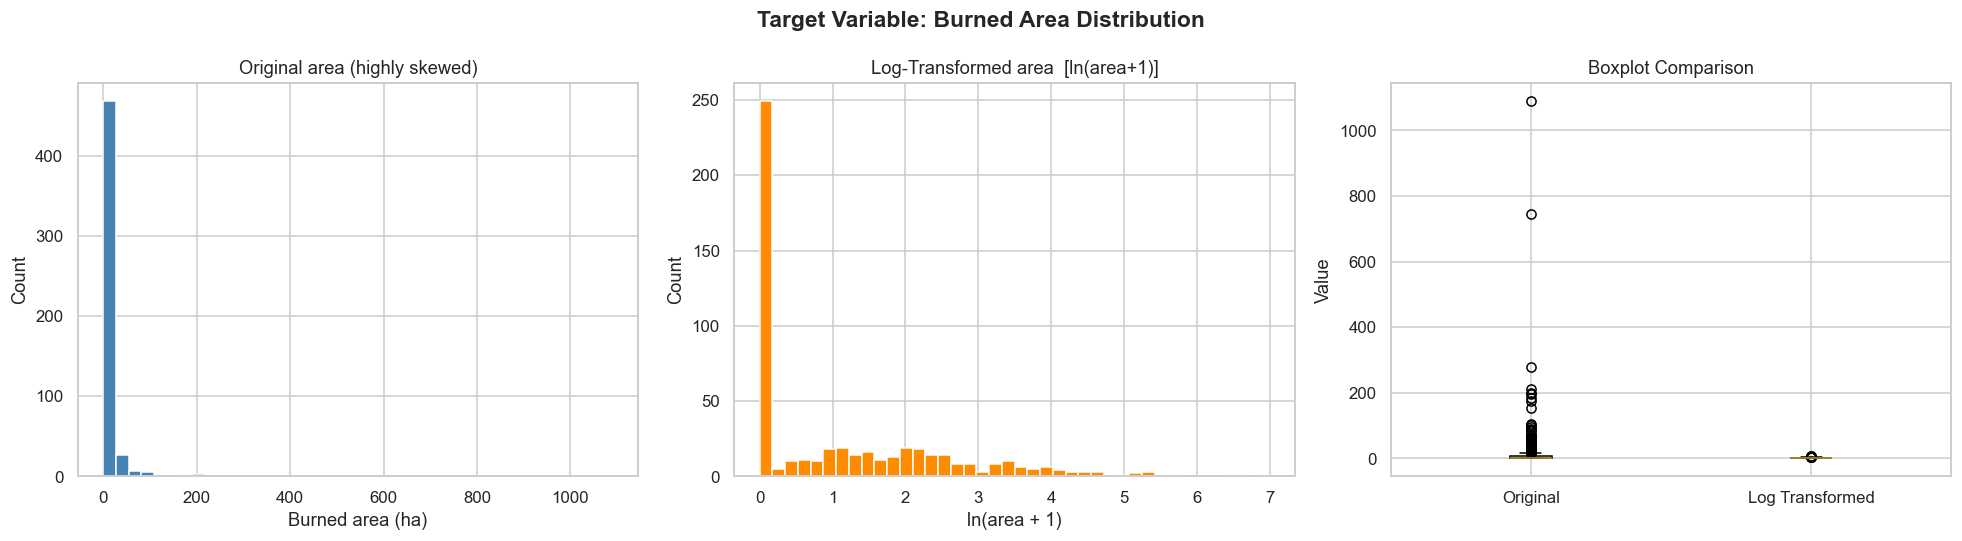

Original area — Skewness: 12.847
Log-transformed — Skewness: 1.218

Percentage of fires with area == 0: 47.8%


In [7]:
# ── The 'area' column (burned hectares) is very skewed.
#    We plot it BEFORE and AFTER log-transform to see the difference.
#    Using ln(area + 1) so that zero-area fires remain = 0 after transform. ──

area_original = df["area"]                      # Raw values
area_log      = np.log1p(df["area"])            # log(x+1) transform

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Target Variable: Burned Area Distribution", fontsize=15, fontweight="bold")

# --- Plot 1: Raw histogram ---
axes[0].hist(area_original, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Original area (highly skewed)")
axes[0].set_xlabel("Burned area (ha)")
axes[0].set_ylabel("Count")

# --- Plot 2: Log-transformed histogram ---
axes[1].hist(area_log, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Log-Transformed area  [ln(area+1)]")
axes[1].set_xlabel("ln(area + 1)")
axes[1].set_ylabel("Count")

# --- Plot 3: Box plots side by side ---
axes[2].boxplot(
    [area_original.values, area_log.values],
    labels=["Original", "Log Transformed"],
    patch_artist=True,
    boxprops=dict(facecolor="lightcyan")
)
axes[2].set_title("Boxplot Comparison")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

print(f"Original area — Skewness: {area_original.skew():.3f}")
print(f"Log-transformed — Skewness: {area_log.skew():.3f}")
print(f"\nPercentage of fires with area == 0: {(area_original == 0).mean() * 100:.1f}%")

### 3.3 Feature Distributions

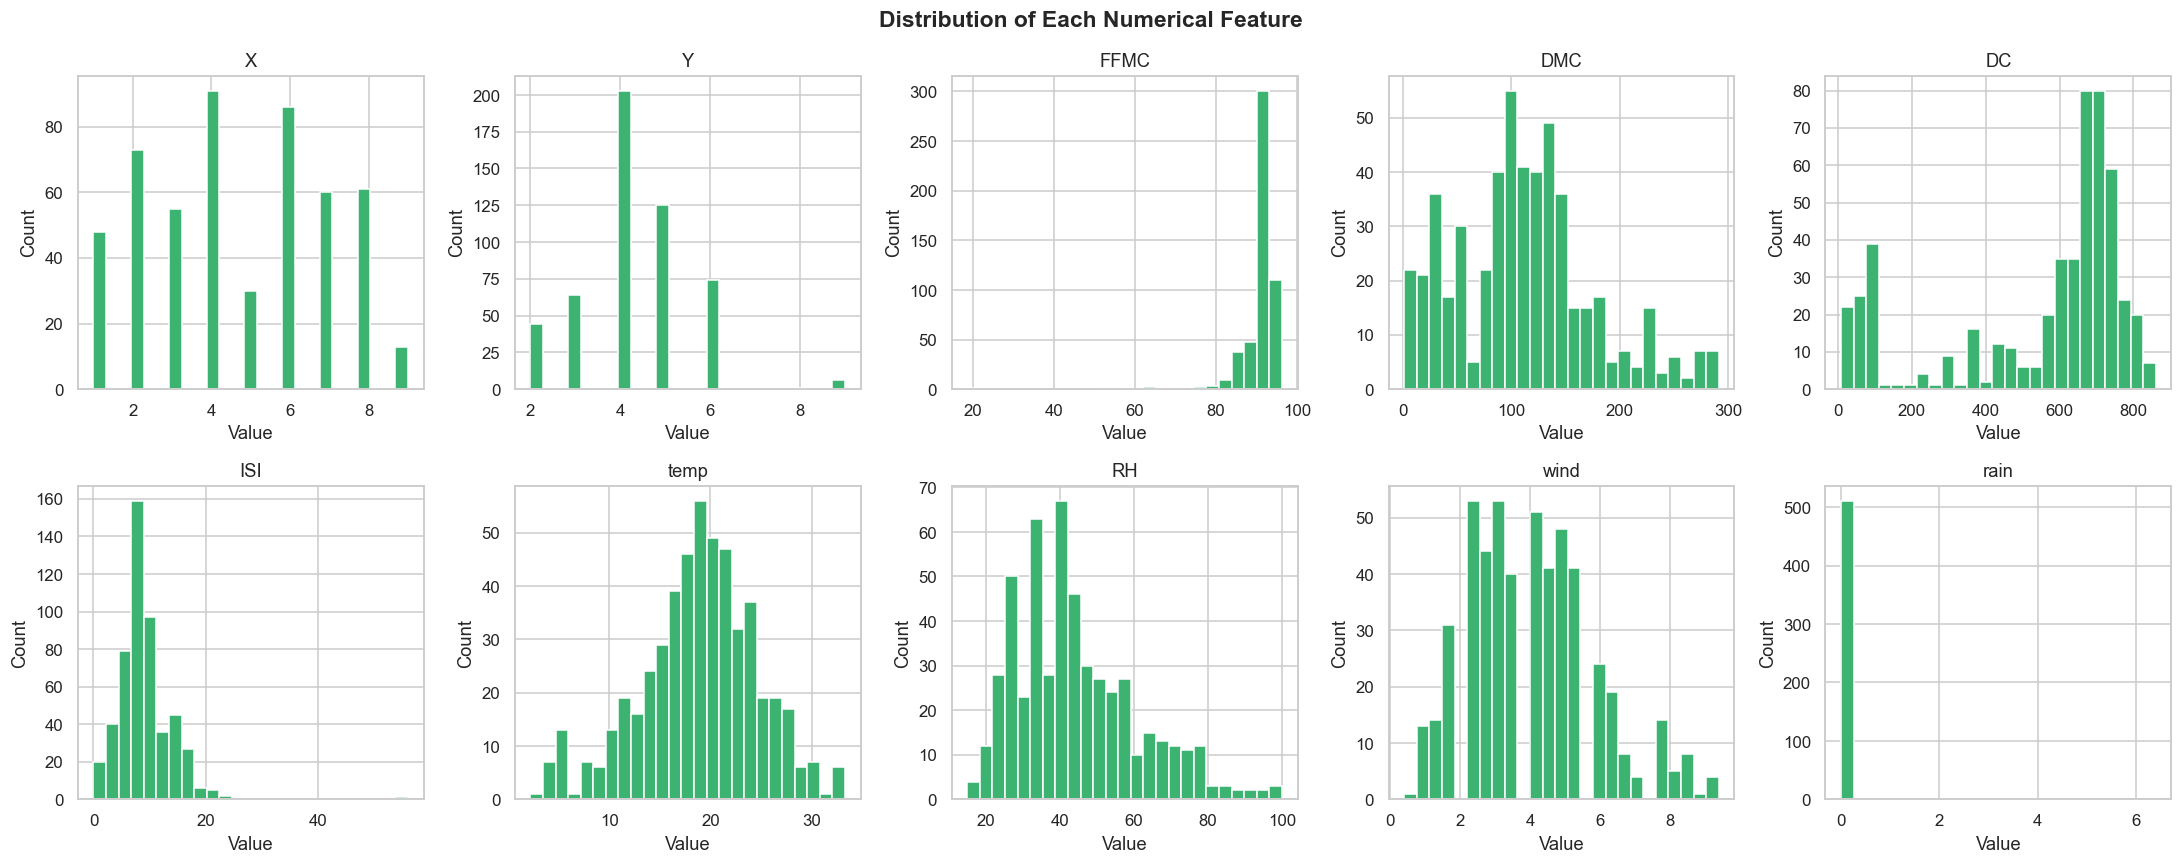

In [8]:
# ── Plot histograms for all numerical features to understand their spread ──

# Identify numerical features (exclude categorical: month, day)
numerical_features = ["X", "Y", "FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribution of Each Numerical Feature", fontsize=15, fontweight="bold")
axes = axes.flatten()   # Flatten 2D array of axes into 1D for easy looping

for idx, feature_name in enumerate(numerical_features):
    axes[idx].hist(df[feature_name], bins=25, color="mediumseagreen", edgecolor="white")
    axes[idx].set_title(feature_name)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 3.4 Categorical Features — Month and Day

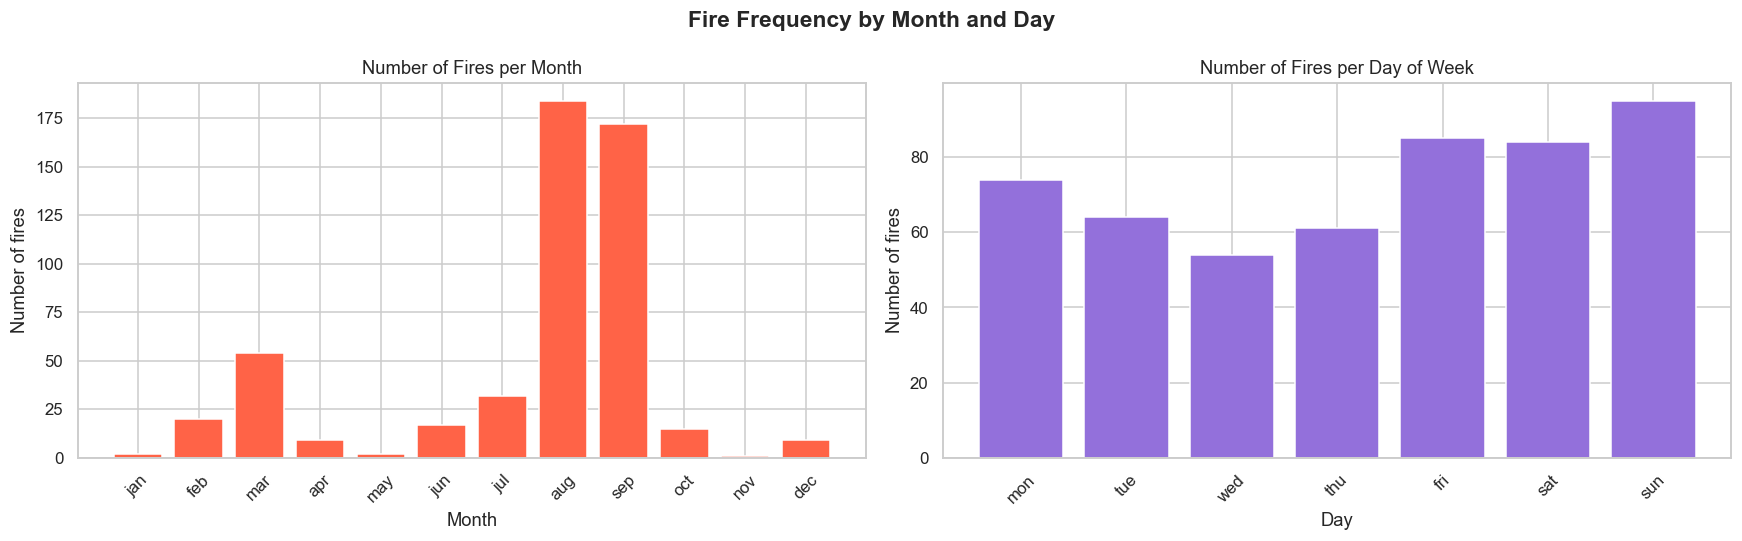

In [9]:
# ── Count how many fires occurred in each month and each day of the week ──

# Ordered months & days so the x-axis is chronological
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
day_order   = ["mon","tue","wed","thu","fri","sat","sun"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Fire Frequency by Month and Day", fontsize=15, fontweight="bold")

# Month counts
month_counts = df["month"].value_counts().reindex(month_order)
axes[0].bar(month_counts.index, month_counts.values, color="tomato", edgecolor="white")
axes[0].set_title("Number of Fires per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of fires")
axes[0].tick_params(axis="x", rotation=45)

# Day counts
day_counts = df["day"].value_counts().reindex(day_order)
axes[1].bar(day_counts.index, day_counts.values, color="mediumpurple", edgecolor="white")
axes[1].set_title("Number of Fires per Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of fires")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

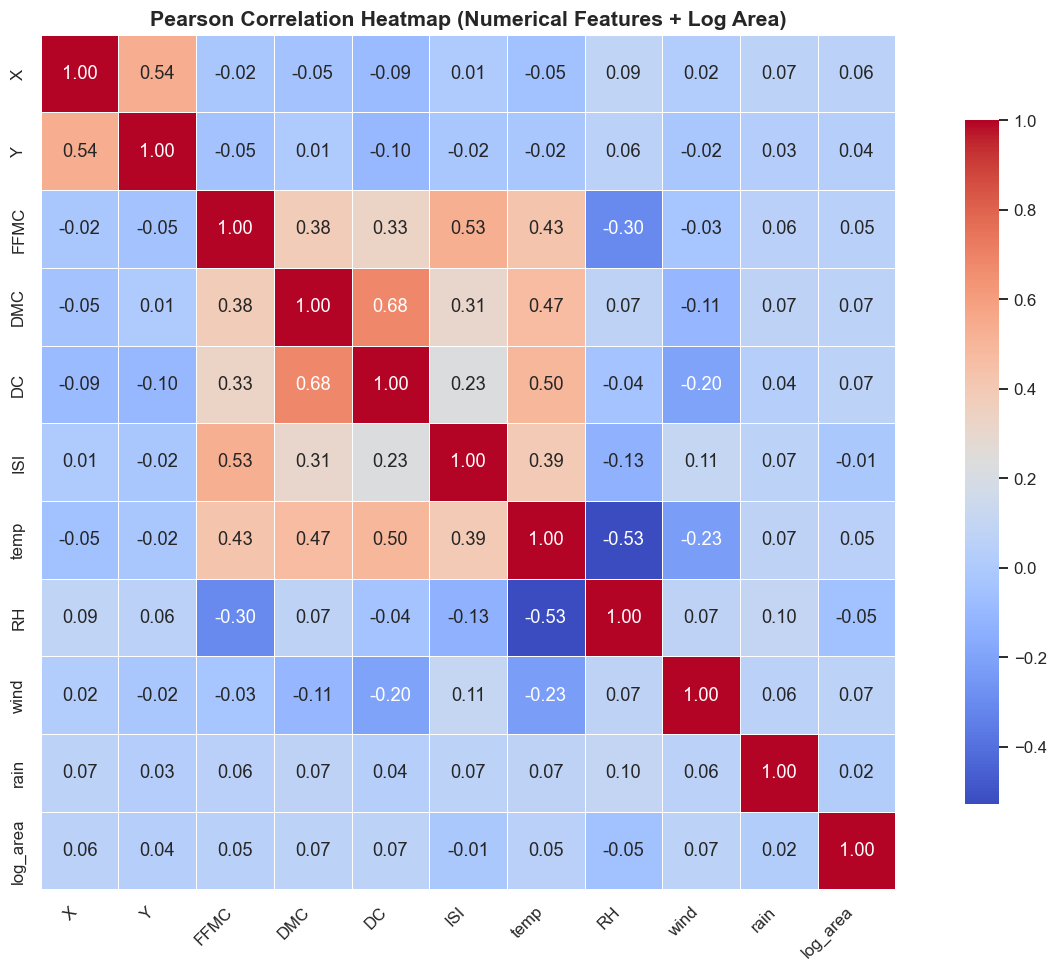


Correlation of each feature with log_area (target):
DMC     0.067153
wind    0.066973
DC      0.066360
X       0.061995
temp    0.053487
FFMC    0.046799
Y       0.038838
rain    0.023311
ISI    -0.010347
RH     -0.053662


In [10]:
# ── Correlation shows which numerical features are strongly related to each other
#    and to the target variable. Values close to +1 or -1 are strongly correlated. ──

# Add the log-transformed target to the dataframe temporarily for correlation check
df_corr = df[numerical_features + ["area"]].copy()
df_corr["log_area"] = np.log1p(df_corr["area"])

correlation_matrix = df_corr.drop(columns=["area"]).corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Print correlation values inside each cell
    fmt=".2f",
    cmap="coolwarm",     # Red = positive, blue = negative correlation
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Heatmap (Numerical Features + Log Area)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print features most correlated with the target
print("\nCorrelation of each feature with log_area (target):")
print(correlation_matrix["log_area"].drop("log_area").sort_values(ascending=False).to_string())

### 3.6 Boxplots — Spotting Outliers

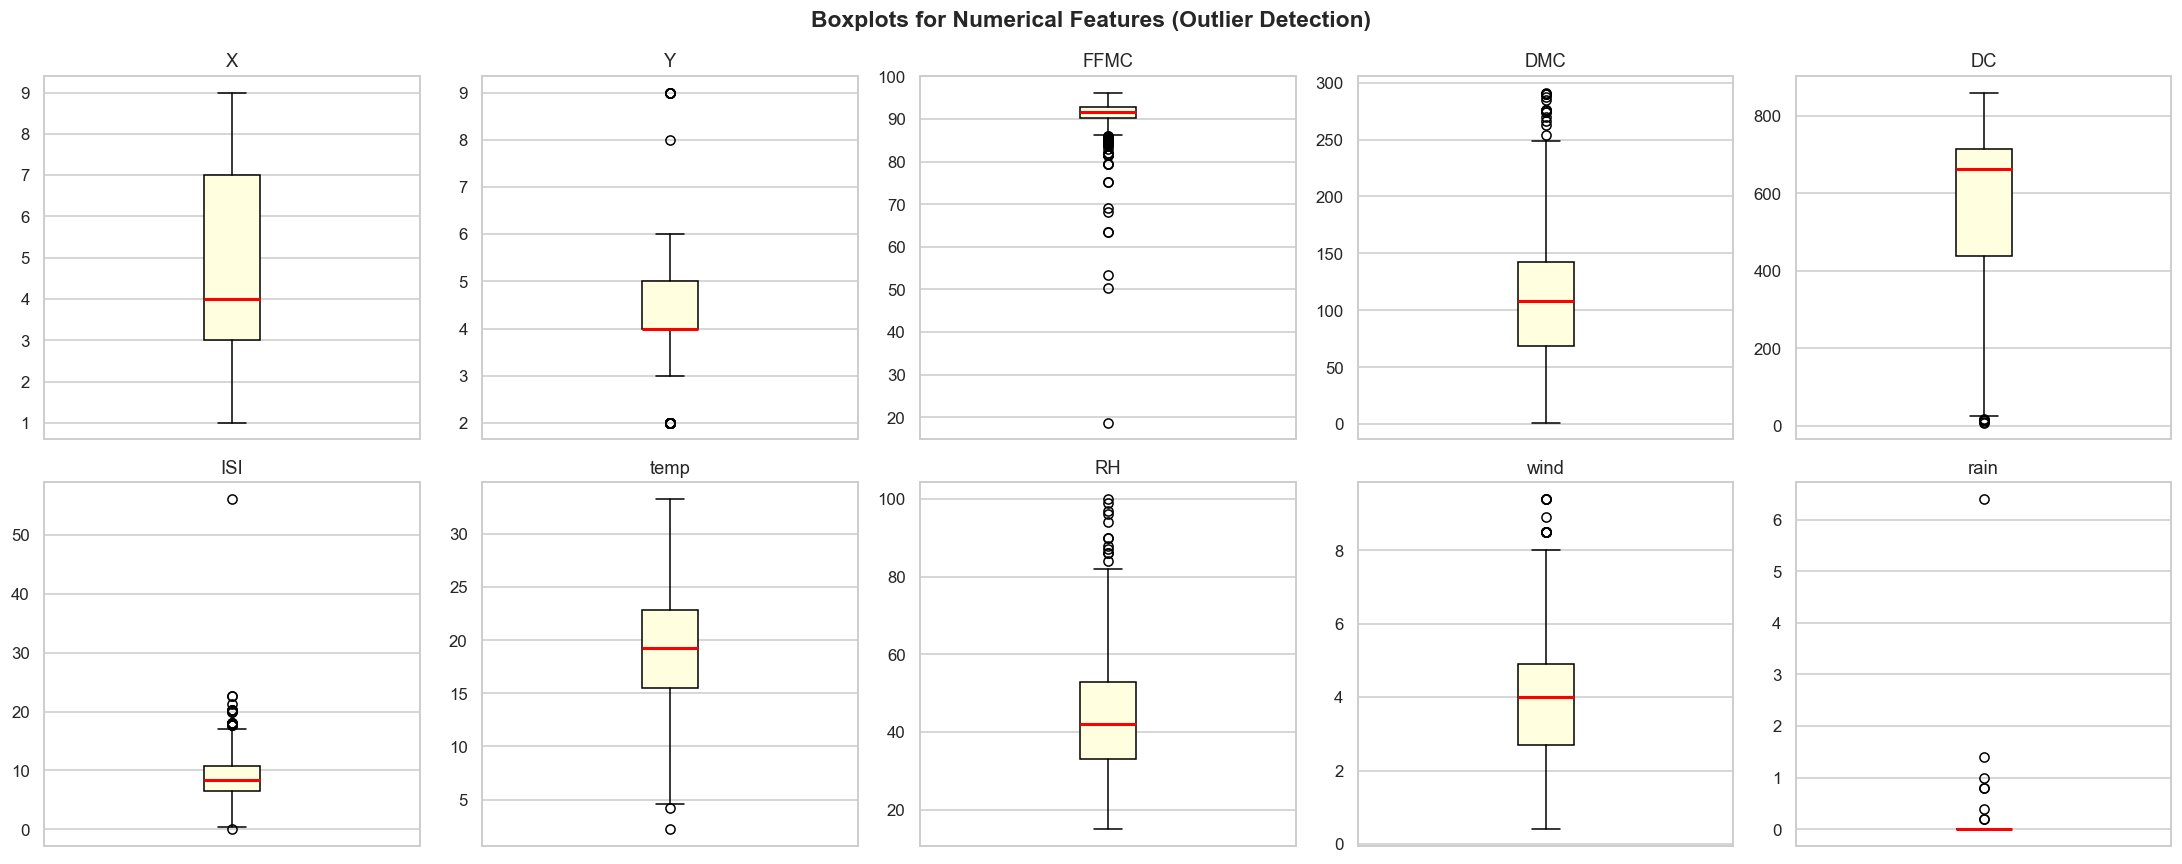

In [11]:
# ── Boxplots help us visually spot outliers (dots outside the whiskers) ──

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Boxplots for Numerical Features (Outlier Detection)", fontsize=15, fontweight="bold")
axes = axes.flatten()

for idx, feature_name in enumerate(numerical_features):
    axes[idx].boxplot(
        df[feature_name].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="lightyellow"),
        medianprops=dict(color="red", linewidth=2)
    )
    axes[idx].set_title(feature_name)
    axes[idx].set_xticks([])

plt.tight_layout()
plt.show()

---
## Step 4 — Preprocessing
### 4.1 Encode Categorical Features & Apply Log Transform to Target

In [12]:
# ── We need to convert text columns (month, day) into numbers
#    because ML algorithms work only with numbers. ──

# Copy the original feature DataFrame to avoid modifying the raw data
df_processed = df.copy()

# --- Label Encode 'month' and 'day' ---
# LabelEncoder converts each unique string to an integer (alphabetically/by appearance)
label_enc = LabelEncoder()
df_processed["month"] = label_enc.fit_transform(df_processed["month"])
df_processed["day"]   = label_enc.fit_transform(df_processed["day"])

# --- Apply log(x+1) to the target 'area' column ---
# This reduces the skewness and makes prediction easier for linear models
df_processed["area"] = np.log1p(df_processed["area"])

print("Unique encoded values for 'month':", sorted(df_processed["month"].unique()))
print("Unique encoded values for 'day'  :", sorted(df_processed["day"].unique()))
print()
print("Log-transformed target stats:")
print(df_processed["area"].describe())

display(df_processed.head())

Unique encoded values for 'month': [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Unique encoded values for 'day'  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Log-transformed target stats:
count    517.000000
mean       1.111026
std        1.398436
min        0.000000
25%        0.000000
50%        0.418710
75%        2.024193
max        6.995620
Name: area, dtype: float64


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,7,0,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,5,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,2,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,7,0,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,7,3,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### 4.2 Train / Test Split

In [13]:
# ── Separate features (X) and the target (y) ──
X_all = df_processed.drop(columns=["area"])   # All 12 input features
y_all = df_processed["area"]                  # Log-transformed burned area

# ── Split into 80% training data and 20% test data ──
# 'random_state' ensures we get the same split every time we run the notebook
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=RANDOM_SEED
)

print(f"Training samples : {X_train.shape[0]}  ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"Test samples     : {X_test.shape[0]}   ({X_test.shape[0]/len(X_all)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

Training samples : 413  (79.9%)
Test samples     : 104   (20.1%)
Number of features: 12


### 4.3 Feature Scaling (StandardScaler)

In [14]:
# ── StandardScaler centres each feature to mean=0 and scales to std=1.
#    This is CRITICAL for Linear Regression and KNN, which are sensitive to feature scale.
#    Tree-based models (Decision Tree, Random Forest) do NOT require scaling.
#    We scale here and use the scaled data for Linear Regression and KNN,
#    but use the unscaled data for tree-based models. ──

scaler = StandardScaler()

# IMPORTANT: we fit the scaler ONLY on training data, then transform both sets.
# If we fit on all data, information from the test set would 'leak' into training.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Feature scaling applied.")
print("Mean of scaled training features (should be ~0):")
print(X_train_scaled.mean().round(3).to_string())

Feature scaling applied.
Mean of scaled training features (should be ~0):
X        0.0
Y       -0.0
month    0.0
day     -0.0
FFMC    -0.0
DMC     -0.0
DC      -0.0
ISI     -0.0
temp     0.0
RH       0.0
wind    -0.0
rain    -0.0


---
## Utility — Evaluation Helper Function

This function will be reused for every algorithm to keep the code clean and consistent.

In [15]:
# ── A reusable function that prints and returns all key regression metrics ──

def evaluate_model(model_name, y_true, y_predicted):
    """
    Compute and display MAE, MSE, RMSE, and R² for a regression model.

    Parameters
    ----------
    model_name   : str   — Human-readable name used for display
    y_true       : array — Actual target values
    y_predicted  : array — Predicted target values from the model

    Returns
    -------
    dict with keys: mae, mse, rmse, r2
    """
    mae  = mean_absolute_error(y_true, y_predicted)
    mse  = mean_squared_error(y_true, y_predicted)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_predicted)

    print(f"\n{'─'*45}")
    print(f" Results for: {model_name}")
    print(f"{'─'*45}")
    print(f"  MAE  (Mean Absolute Error)      : {mae:.4f}")
    print(f"  MSE  (Mean Squared Error)        : {mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)   : {rmse:.4f}")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")
    print(f"{'─'*45}")

    return {"model": model_name, "mae": mae, "mse": mse, "rmse": rmse, "r2": r2}


# ── A function to plot Actual vs Predicted and Residuals side by side ──

def plot_actual_vs_predicted(model_name, y_true, y_predicted, color="steelblue"):
    """
    Draws two diagnostic plots:
      Left  — Scatter: actual vs predicted  (perfect model = diagonal line)
      Right — Residual plot: predicted vs (actual - predicted)  (good model = horizontal band at 0)
    """
    residuals = np.array(y_true) - np.array(y_predicted)   # Errors = actual - predicted

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Diagnostic Plots", fontsize=14, fontweight="bold")

    # --- Left plot: Actual vs Predicted ---
    axes[0].scatter(y_true, y_predicted, alpha=0.5, color=color, edgecolors="white", s=50)
    # Draw the perfect-prediction line (where actual == predicted)
    min_val = min(min(y_true), min(y_predicted))
    max_val = max(max(y_true), max(y_predicted))
    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect fit")
    axes[0].set_xlabel("Actual log(area+1)")
    axes[0].set_ylabel("Predicted log(area+1)")
    axes[0].set_title("Actual vs Predicted")
    axes[0].legend()

    # --- Right plot: Residuals ---
    axes[1].scatter(y_predicted, residuals, alpha=0.5, color=color, edgecolors="white", s=50)
    axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)  # Zero-error reference line
    axes[1].set_xlabel("Predicted log(area+1)")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title("Residual Plot")

    plt.tight_layout()
    plt.show()


# Dictionary to store all model results for the final comparison
all_results = {}

print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Step 5 — Algorithm 1: Linear Regression

**How it works**: Fits a straight line (hyperplane in multiple dimensions) through the data  
by minimising the sum of squared errors. It assumes a **linear** relationship between features and target.

In [16]:
# ── Linear Regression uses the SCALED data because it is scale-sensitive ──

# --- Create and train the model ---
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# --- Make predictions on the test set ---
y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained!")
print(f"\nModel intercept (bias term): {linear_model.intercept_:.4f}")

# --- Show coefficients for each feature ---
coef_df = pd.DataFrame({
    "Feature"    : X_train.columns,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", ascending=False)

print("\nFeature coefficients (larger absolute value = more influence):")
display(coef_df)

Linear Regression model trained!

Model intercept (bias term): 1.1036

Feature coefficients (larger absolute value = more influence):


,Feature,Coefficient
5,DMC,0.196083
2,month,0.108238
0,X,0.105178
10,wind,0.081709
4,FFMC,0.070145
11,rain,0.039355
1,Y,0.024620
3,day,0.006951
8,temp,-0.012022
6,DC,-0.031861


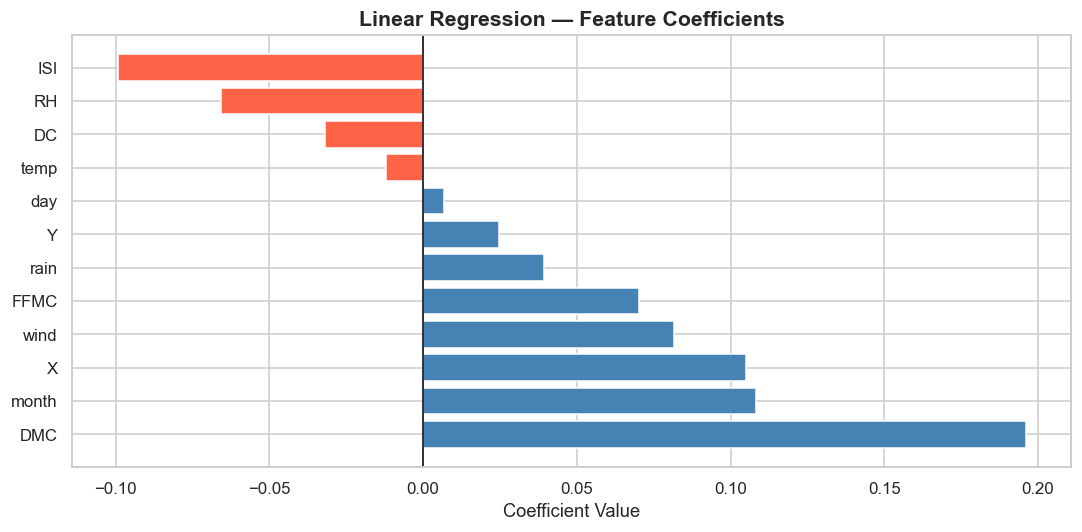

In [17]:
# ── Visualise the Linear Regression coefficients as a bar chart ──

plt.figure(figsize=(10, 5))
colors = ["tomato" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
plt.axvline(x=0, color="black", linewidth=1)
plt.title("Linear Regression — Feature Coefficients", fontsize=14, fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


─────────────────────────────────────────────
 Results for: Linear Regression
─────────────────────────────────────────────
  MAE  (Mean Absolute Error)      : 1.1992
  MSE  (Mean Squared Error)        : 2.2059
  RMSE (Root Mean Squared Error)   : 1.4852
  R²   (Coefficient of Determination): -0.0036
─────────────────────────────────────────────


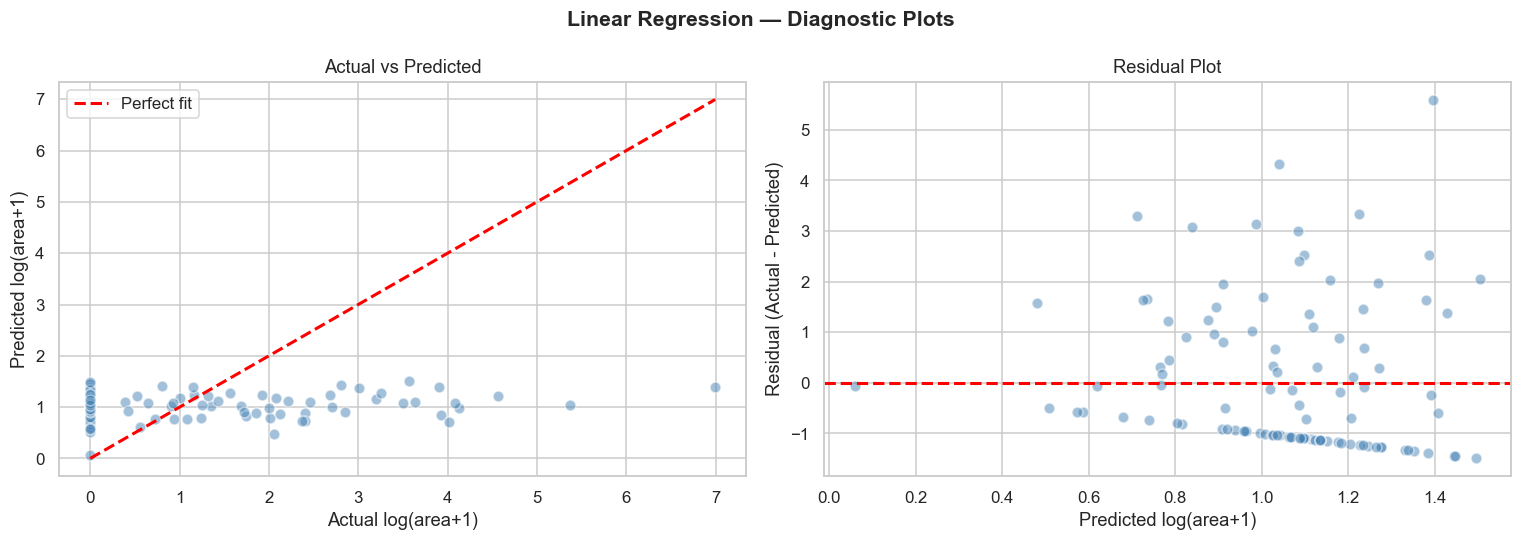

In [18]:
# ── Evaluate the Linear Regression model on the test set ──
linear_results = evaluate_model("Linear Regression", y_test, y_pred_linear)

# Store in our comparison dictionary
all_results["Linear Regression"] = linear_results

# ── Diagnostic plots ──
plot_actual_vs_predicted("Linear Regression", y_test.values, y_pred_linear, color="steelblue")

Linear Regression — 10-Fold Cross-Validation RMSE per fold:
  Fold  1: RMSE = 1.4495
  Fold  2: RMSE = 1.5182
  Fold  3: RMSE = 1.2321
  Fold  4: RMSE = 1.5187
  Fold  5: RMSE = 1.2451
  Fold  6: RMSE = 1.8475
  Fold  7: RMSE = 1.3706
  Fold  8: RMSE = 1.6990
  Fold  9: RMSE = 1.1947
  Fold 10: RMSE = 1.2298

  Average RMSE : 1.4305
  Std Dev RMSE : 0.2086


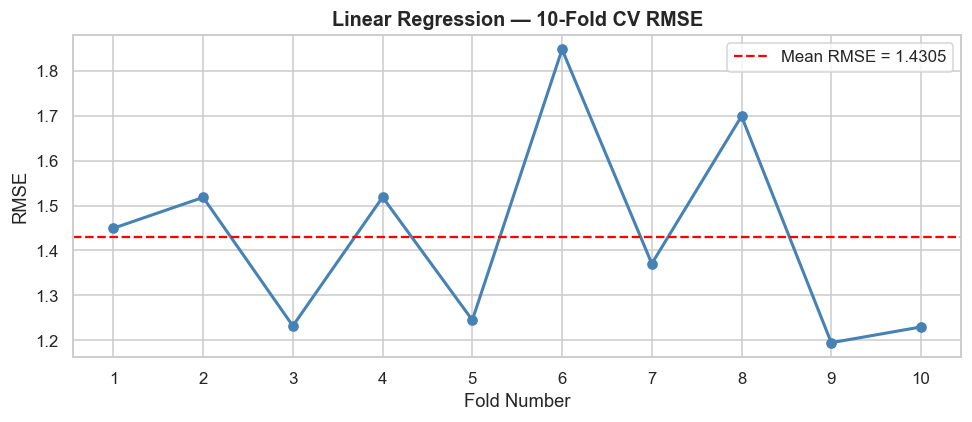

In [19]:
# ── Cross-Validation for Linear Regression ──
# Instead of evaluating on just one train/test split, cross-validation (CV)
# divides data into K equally-sized folds, trains on K-1 folds, tests on 1,
# repeats K times, and averages the scores. Gives a more reliable estimate.

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# scoring='neg_mean_squared_error' because sklearn maximises, so returns negative MSE
cv_neg_mse_linear = cross_val_score(
    estimator=LinearRegression(),
    X=X_all,              # Use ALL data for cross-validation
    y=y_all,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

cv_rmse_linear = np.sqrt(-cv_neg_mse_linear)  # Convert to RMSE

print("Linear Regression — 10-Fold Cross-Validation RMSE per fold:")
for fold_number, fold_rmse in enumerate(cv_rmse_linear, start=1):
    print(f"  Fold {fold_number:2d}: RMSE = {fold_rmse:.4f}")
print(f"\n  Average RMSE : {cv_rmse_linear.mean():.4f}")
print(f"  Std Dev RMSE : {cv_rmse_linear.std():.4f}")

# Store CV result
all_results["Linear Regression"]["cv_rmse_mean"] = cv_rmse_linear.mean()
all_results["Linear Regression"]["cv_rmse_std"]  = cv_rmse_linear.std()

# ── Plot CV RMSE across folds ──
plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_rmse_linear, marker="o", color="steelblue", linewidth=2)
plt.axhline(y=cv_rmse_linear.mean(), color="red", linestyle="--", label=f"Mean RMSE = {cv_rmse_linear.mean():.4f}")
plt.title("Linear Regression — 10-Fold CV RMSE", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 6 — Algorithm 2: Decision Tree Regressor

**How it works**: Recursively splits the dataset using if-else rules on feature values,  
creating a tree structure. Leaf nodes predict the mean value of training samples that fall there.  
**Key hyperparameter**: `max_depth` — controls tree depth (deeper = more complex = risk of overfitting).

Best max_depth found by GridSearchCV: 2


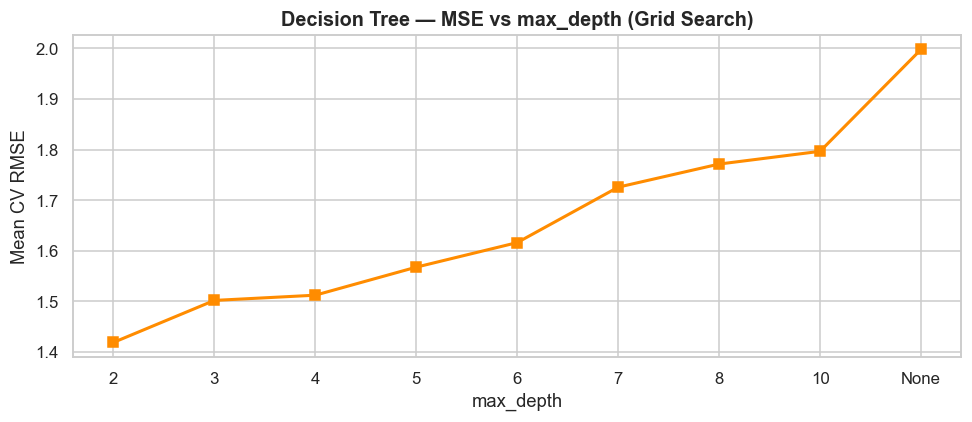

In [20]:
# ── Decision Trees do NOT require scaled data, so we use X_train / X_test directly ──

# --- Step 1: Find the best max_depth using GridSearchCV ---
# GridSearchCV trains the model for every depth value and picks the one
# with the lowest cross-validated MSE.

depth_candidates = {"max_depth": [2, 3, 4, 5, 6, 7, 8, 10, None]}  # None = unlimited depth

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_SEED),
    param_grid=depth_candidates,
    cv=10,
    scoring="neg_mean_squared_error",
    n_jobs=-1          # Use all CPU cores for speed
)
dt_grid_search.fit(X_train, y_train)

best_depth = dt_grid_search.best_params_["max_depth"]
print(f"Best max_depth found by GridSearchCV: {best_depth}")

# ── Plot how RMSE changes with different max_depth values ──
mean_scores = -dt_grid_search.cv_results_["mean_test_score"]
depth_labels = [str(d) if d is not None else "None" for d in depth_candidates["max_depth"]]

plt.figure(figsize=(9, 4))
plt.plot(depth_labels, np.sqrt(mean_scores), marker="s", color="darkorange", linewidth=2)
plt.title("Decision Tree — MSE vs max_depth (Grid Search)", fontsize=13, fontweight="bold")
plt.xlabel("max_depth")
plt.ylabel("Mean CV RMSE")
plt.tight_layout()
plt.show()


─────────────────────────────────────────────
 Results for: Decision Tree Regressor
─────────────────────────────────────────────
  MAE  (Mean Absolute Error)      : 1.2037
  MSE  (Mean Squared Error)        : 2.1986
  RMSE (Root Mean Squared Error)   : 1.4828
  R²   (Coefficient of Determination): -0.0003
─────────────────────────────────────────────


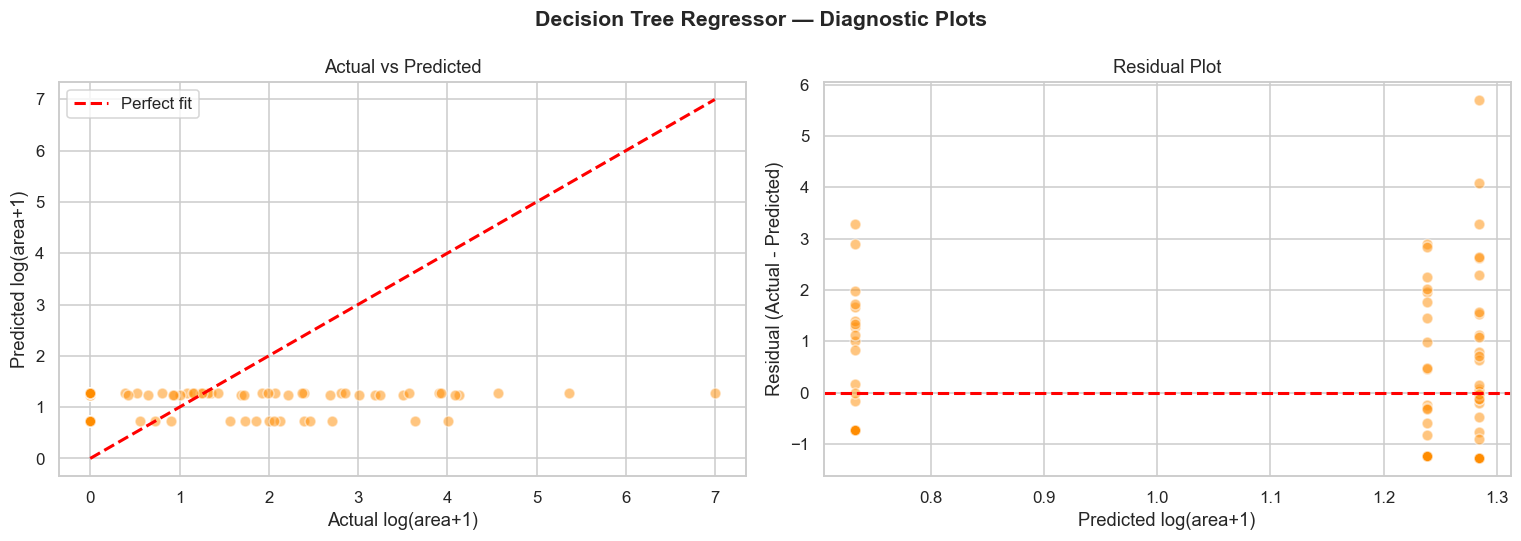

In [21]:
# --- Step 2: Train the best Decision Tree ---
best_dt_model = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=RANDOM_SEED
)
best_dt_model.fit(X_train, y_train)

# --- Make predictions ---
y_pred_dt = best_dt_model.predict(X_test)

# --- Evaluate ---
dt_results = evaluate_model("Decision Tree Regressor", y_test, y_pred_dt)
all_results["Decision Tree"] = dt_results

# --- Diagnostic plots ---
plot_actual_vs_predicted("Decision Tree Regressor", y_test.values, y_pred_dt, color="darkorange")

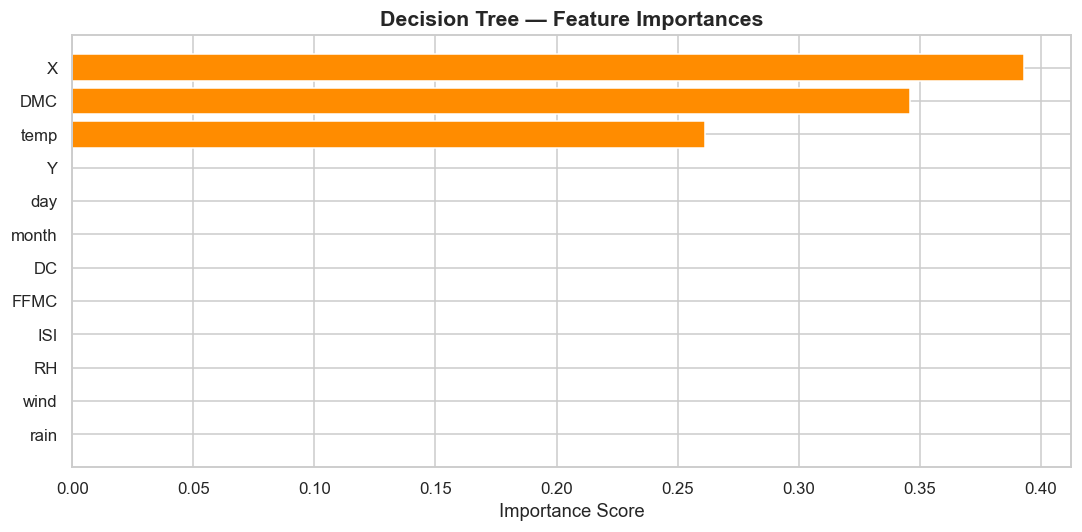

In [22]:
# ── Feature Importances from Decision Tree ──
# Decision Trees assign an importance score to each feature based on
# how much that feature reduces the impurity (error) at each split.

dt_importance_df = pd.DataFrame({
    "Feature"   : X_train.columns,
    "Importance": best_dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(
    dt_importance_df["Feature"],
    dt_importance_df["Importance"],
    color="darkorange", edgecolor="white"
)
plt.title("Decision Tree — Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()             # Most important at the top
plt.tight_layout()
plt.show()

Decision Tree — 10-Fold CV RMSE per fold:
  Fold  1: RMSE = 1.4675
  Fold  2: RMSE = 1.4549
  Fold  3: RMSE = 1.1278
  Fold  4: RMSE = 1.5825
  Fold  5: RMSE = 1.3522
  Fold  6: RMSE = 1.4752
  Fold  7: RMSE = 1.4508
  Fold  8: RMSE = 1.7342
  Fold  9: RMSE = 1.1133
  Fold 10: RMSE = 1.2369

  Average RMSE : 1.3995
  Std Dev RMSE : 0.1860


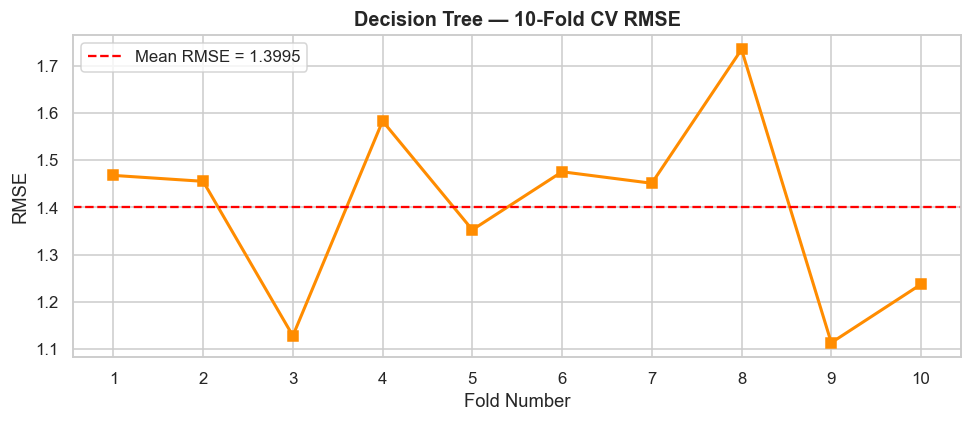

In [23]:
# ── Cross-Validation for Decision Tree (best depth) ──

cv_neg_mse_dt = cross_val_score(
    estimator=DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_SEED),
    X=X_all, y=y_all,
    cv=kfold,
    scoring="neg_mean_squared_error"
)
cv_rmse_dt = np.sqrt(-cv_neg_mse_dt)

print("Decision Tree — 10-Fold CV RMSE per fold:")
for fold_number, fold_rmse in enumerate(cv_rmse_dt, start=1):
    print(f"  Fold {fold_number:2d}: RMSE = {fold_rmse:.4f}")
print(f"\n  Average RMSE : {cv_rmse_dt.mean():.4f}")
print(f"  Std Dev RMSE : {cv_rmse_dt.std():.4f}")

all_results["Decision Tree"]["cv_rmse_mean"] = cv_rmse_dt.mean()
all_results["Decision Tree"]["cv_rmse_std"]  = cv_rmse_dt.std()

plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_rmse_dt, marker="s", color="darkorange", linewidth=2)
plt.axhline(y=cv_rmse_dt.mean(), color="red", linestyle="--", label=f"Mean RMSE = {cv_rmse_dt.mean():.4f}")
plt.title("Decision Tree — 10-Fold CV RMSE", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 7 — Algorithm 3: Random Forest Regressor

**How it works**: Builds many Decision Trees on random subsets of data and features,  
then **averages** their predictions. This reduces overfitting and generally achieves  
better accuracy than a single Decision Tree.  
**Key hyperparameters**: `n_estimators` (number of trees), `max_depth`.

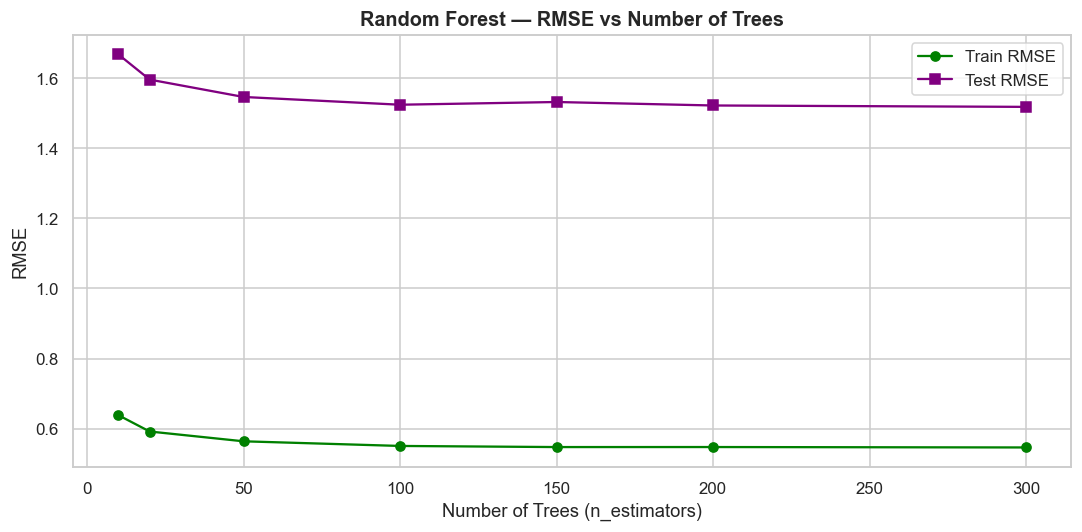

Best n_estimators: 300 (lowest test RMSE = 1.5183)


In [24]:
# ── Step 1: Tune n_estimators (number of trees) ──
# More trees = better, but with diminishing returns. Plot shows where it stabilises.

n_trees_to_try = [10, 20, 50, 100, 150, 200, 300]
train_rmse_list = []
test_rmse_list  = []

for n_trees in n_trees_to_try:
    rf = RandomForestRegressor(n_estimators=n_trees, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_preds = rf.predict(X_train)
    test_preds  = rf.predict(X_test)

    train_rmse_list.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    test_rmse_list.append(np.sqrt(mean_squared_error(y_test,  test_preds)))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_to_try, train_rmse_list, marker="o", label="Train RMSE", color="green")
plt.plot(n_trees_to_try, test_rmse_list,  marker="s", label="Test RMSE",  color="purple")
plt.title("Random Forest — RMSE vs Number of Trees", fontsize=13, fontweight="bold")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

# Pick the n_estimators that gives the lowest test RMSE
best_n_trees = n_trees_to_try[np.argmin(test_rmse_list)]
print(f"Best n_estimators: {best_n_trees} (lowest test RMSE = {min(test_rmse_list):.4f})")

In [25]:
# ── Step 2: Fine-tune with GridSearchCV ──

rf_param_grid = {
    "n_estimators": [best_n_trees, best_n_trees + 50],
    "max_depth"   : [None, 5, 8, 10],
    "min_samples_split": [2, 5]       # Minimum samples required to split a node
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)

print("Best hyperparameters for Random Forest:")
print(rf_grid_search.best_params_)

Best hyperparameters for Random Forest:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 350}



─────────────────────────────────────────────
 Results for: Random Forest Regressor
─────────────────────────────────────────────
  MAE  (Mean Absolute Error)      : 1.1813
  MSE  (Mean Squared Error)        : 2.1560
  RMSE (Root Mean Squared Error)   : 1.4683
  R²   (Coefficient of Determination): 0.0191
─────────────────────────────────────────────


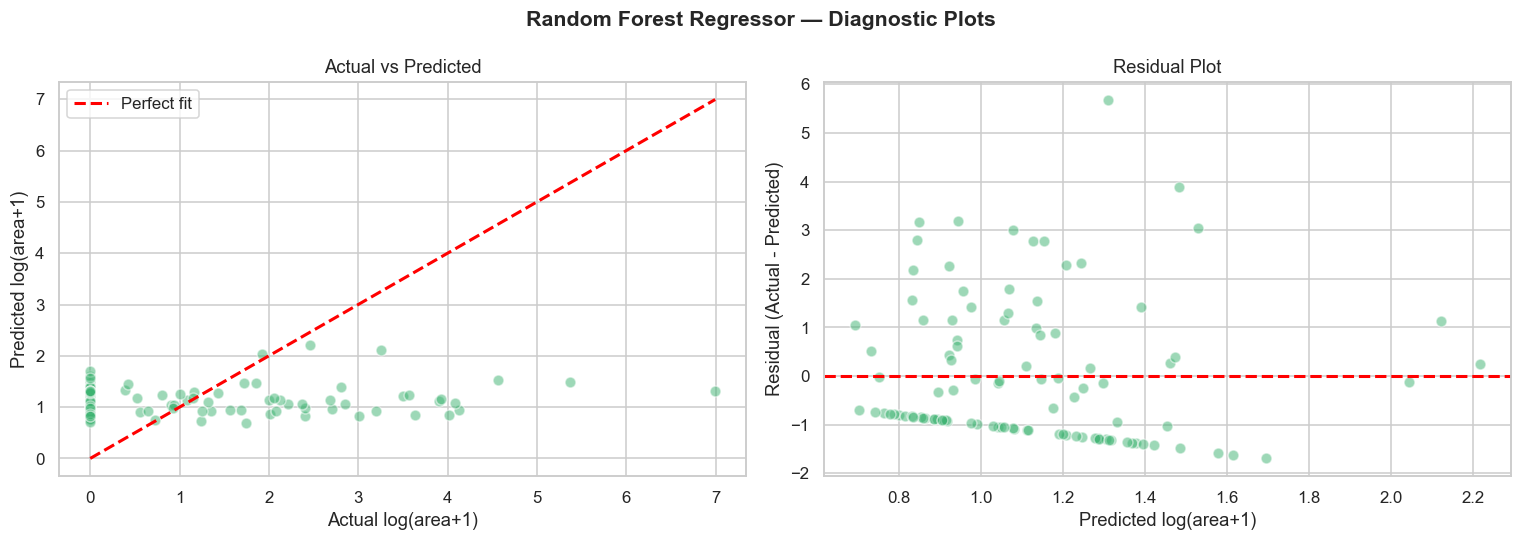

In [26]:
# --- Train the best Random Forest ---
best_rf_model = rf_grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)

# --- Evaluate ---
rf_results = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)
all_results["Random Forest"] = rf_results

# --- Diagnostic plots ---
plot_actual_vs_predicted("Random Forest Regressor", y_test.values, y_pred_rf, color="mediumseagreen")

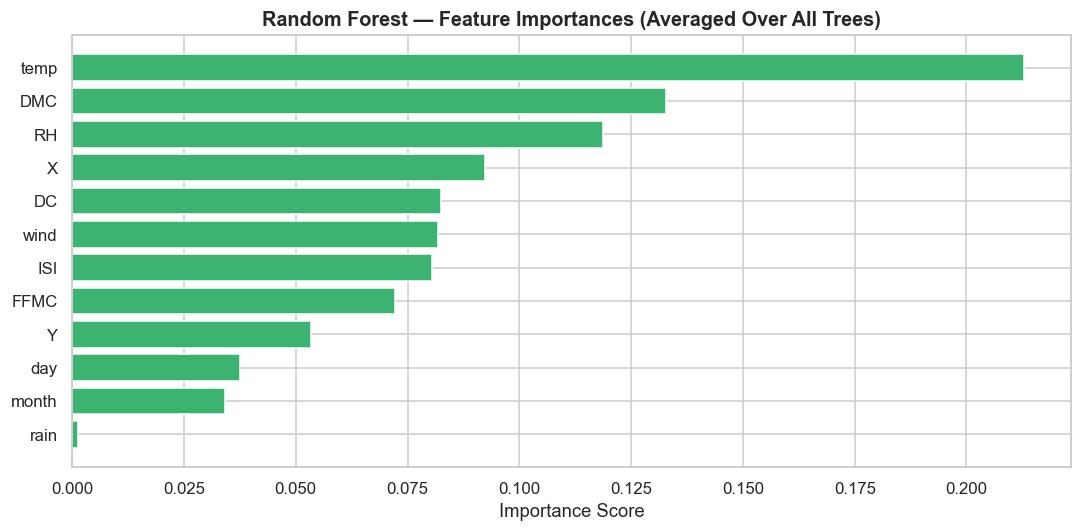

Top 5 most important features:
Feature  Importance
   temp    0.212821
    DMC    0.132900
     RH    0.118802
      X    0.092397
     DC    0.082500


In [27]:
# ── Feature Importances from Random Forest ──
# Averaged over all trees → more stable than a single Decision Tree

rf_importance_df = pd.DataFrame({
    "Feature"   : X_train.columns,
    "Importance": best_rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(
    rf_importance_df["Feature"],
    rf_importance_df["Importance"],
    color="mediumseagreen", edgecolor="white"
)
plt.title("Random Forest — Feature Importances (Averaged Over All Trees)", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(rf_importance_df.head().to_string(index=False))

Random Forest — 10-Fold CV RMSE per fold:
  Fold  1: RMSE = 1.4984
  Fold  2: RMSE = 1.4565
  Fold  3: RMSE = 1.1699
  Fold  4: RMSE = 1.5230
  Fold  5: RMSE = 1.3120
  Fold  6: RMSE = 1.5168
  Fold  7: RMSE = 1.4313
  Fold  8: RMSE = 1.7390
  Fold  9: RMSE = 1.1432
  Fold 10: RMSE = 1.2729

  Average RMSE : 1.4063
  Std Dev RMSE : 0.1732


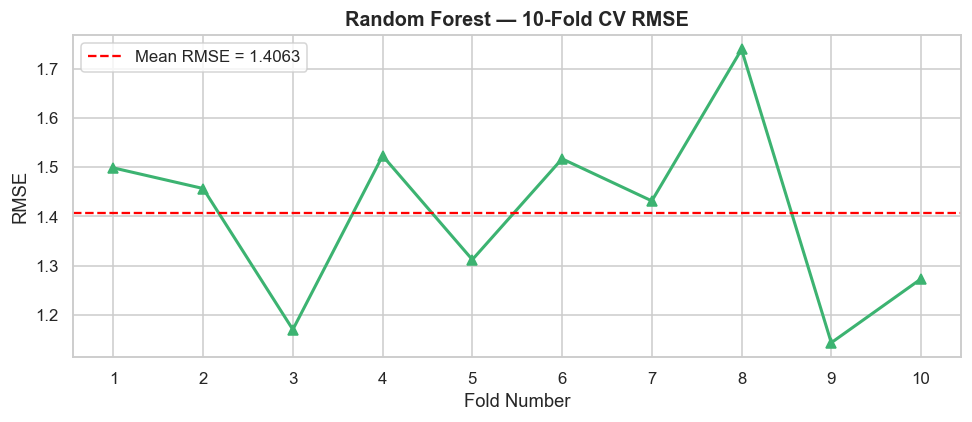

In [28]:
# ── Cross-Validation for Random Forest ──

cv_neg_mse_rf = cross_val_score(
    estimator=RandomForestRegressor(**rf_grid_search.best_params_, random_state=RANDOM_SEED, n_jobs=-1),
    X=X_all, y=y_all,
    cv=kfold,
    scoring="neg_mean_squared_error"
)
cv_rmse_rf = np.sqrt(-cv_neg_mse_rf)

print("Random Forest — 10-Fold CV RMSE per fold:")
for fold_number, fold_rmse in enumerate(cv_rmse_rf, start=1):
    print(f"  Fold {fold_number:2d}: RMSE = {fold_rmse:.4f}")
print(f"\n  Average RMSE : {cv_rmse_rf.mean():.4f}")
print(f"  Std Dev RMSE : {cv_rmse_rf.std():.4f}")

all_results["Random Forest"]["cv_rmse_mean"] = cv_rmse_rf.mean()
all_results["Random Forest"]["cv_rmse_std"]  = cv_rmse_rf.std()

plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_rmse_rf, marker="^", color="mediumseagreen", linewidth=2)
plt.axhline(y=cv_rmse_rf.mean(), color="red", linestyle="--", label=f"Mean RMSE = {cv_rmse_rf.mean():.4f}")
plt.title("Random Forest — 10-Fold CV RMSE", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 8 — Algorithm 4: K-Nearest Neighbours (KNN) Regressor

**How it works**: For every new data point, KNN finds the K closest training samples  
(by Euclidean distance) and predicts the **average** of their target values.  
**Key hyperparameter**: `n_neighbors` (K) — small K = noisy, large K = too smooth.

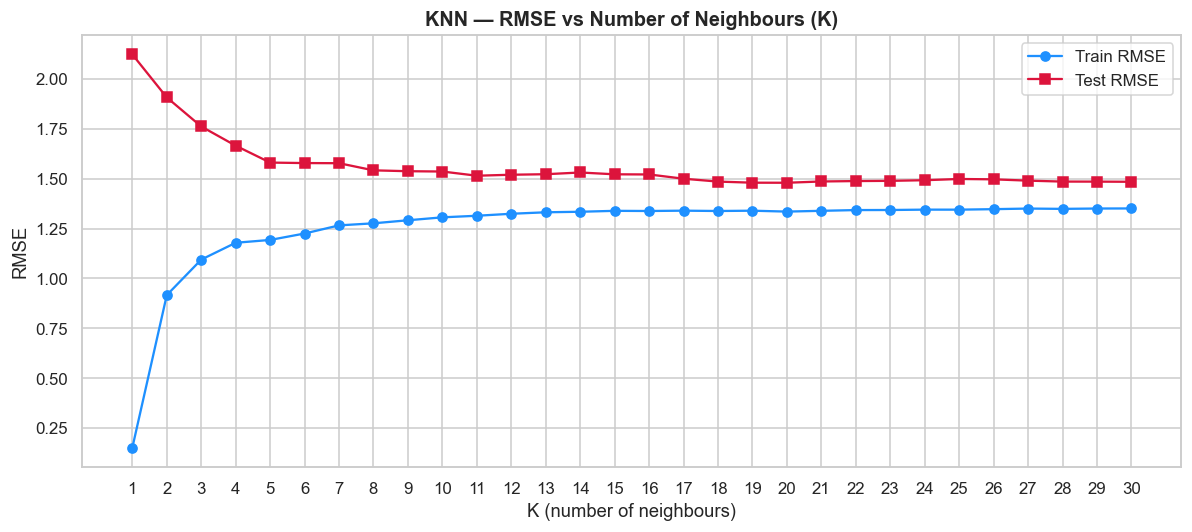

Best K = 20  (lowest test RMSE = 1.4800)


In [29]:
# ── KNN is VERY sensitive to scale, so we use the SCALED data ──

# --- Find the best K by testing K = 1 to 30 ---
k_values        = range(1, 31)
knn_train_rmse  = []
knn_test_rmse   = []

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    train_preds = knn_model.predict(X_train_scaled)
    test_preds  = knn_model.predict(X_test_scaled)

    knn_train_rmse.append(np.sqrt(mean_squared_error(y_train, train_preds)))
    knn_test_rmse.append(np.sqrt(mean_squared_error(y_test,  test_preds)))

# ── Plot RMSE vs K ──
plt.figure(figsize=(11, 5))
plt.plot(k_values, knn_train_rmse, marker="o", label="Train RMSE", color="dodgerblue")
plt.plot(k_values, knn_test_rmse,  marker="s", label="Test RMSE",  color="crimson")
plt.title("KNN — RMSE vs Number of Neighbours (K)", fontsize=13, fontweight="bold")
plt.xlabel("K (number of neighbours)")
plt.ylabel("RMSE")
plt.xticks(range(1, 31))
plt.legend()
plt.tight_layout()
plt.show()

# Choose K that gives the minimum test RMSE
best_k = k_values[np.argmin(knn_test_rmse)]
print(f"Best K = {best_k}  (lowest test RMSE = {min(knn_test_rmse):.4f})")


─────────────────────────────────────────────
 Results for: KNN Regressor (K=20)
─────────────────────────────────────────────
  MAE  (Mean Absolute Error)      : 1.1906
  MSE  (Mean Squared Error)        : 2.1904
  RMSE (Root Mean Squared Error)   : 1.4800
  R²   (Coefficient of Determination): 0.0034
─────────────────────────────────────────────


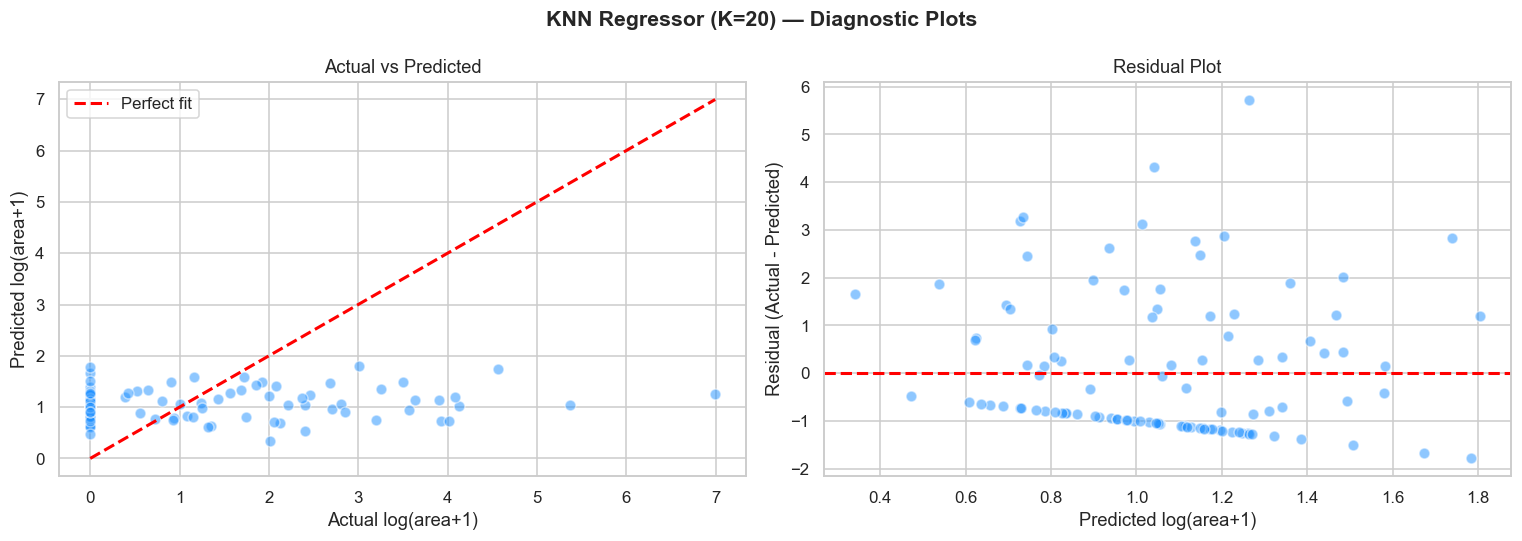

In [30]:
# --- Train the KNN model with the best K ---
best_knn_model = KNeighborsRegressor(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)

y_pred_knn = best_knn_model.predict(X_test_scaled)

# --- Evaluate ---
knn_results = evaluate_model(f"KNN Regressor (K={best_k})", y_test, y_pred_knn)
all_results["KNN"] = knn_results

# --- Diagnostic plots ---
plot_actual_vs_predicted(f"KNN Regressor (K={best_k})", y_test.values, y_pred_knn, color="dodgerblue")

KNN (K=20) — 10-Fold CV RMSE per fold:
  Fold  1: RMSE = 1.5006
  Fold  2: RMSE = 1.4909
  Fold  3: RMSE = 1.2547
  Fold  4: RMSE = 1.5877
  Fold  5: RMSE = 1.2762
  Fold  6: RMSE = 1.5368
  Fold  7: RMSE = 1.4082
  Fold  8: RMSE = 1.7070
  Fold  9: RMSE = 1.1206
  Fold 10: RMSE = 1.2747

  Average RMSE : 1.4157
  Std Dev RMSE : 0.1716


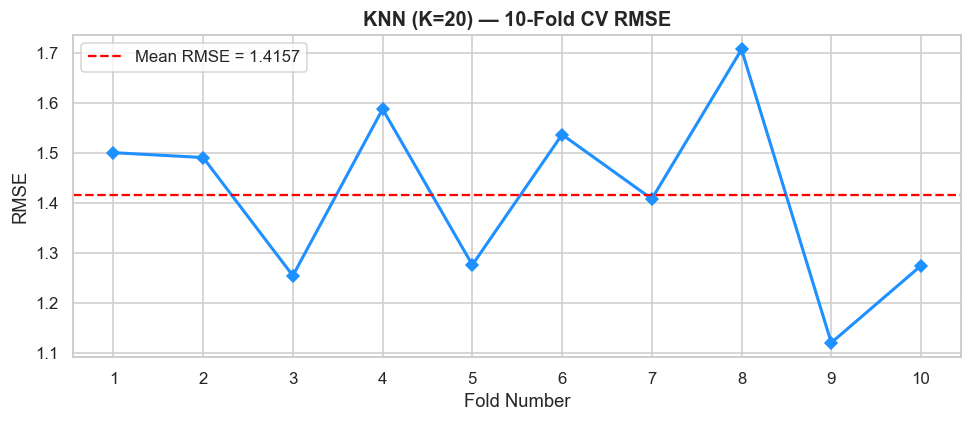

In [31]:
# ── Cross-Validation for KNN (using scaled data) ──

# Note: For proper CV on scaled data, we should use a Pipeline to prevent leakage.
# Here we use already-scaled X_all for simplicity.
from sklearn.pipeline import Pipeline

knn_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsRegressor(n_neighbors=best_k))
])

cv_neg_mse_knn = cross_val_score(
    estimator=knn_cv_pipeline,
    X=X_all, y=y_all,
    cv=kfold,
    scoring="neg_mean_squared_error"
)
cv_rmse_knn = np.sqrt(-cv_neg_mse_knn)

print(f"KNN (K={best_k}) — 10-Fold CV RMSE per fold:")
for fold_number, fold_rmse in enumerate(cv_rmse_knn, start=1):
    print(f"  Fold {fold_number:2d}: RMSE = {fold_rmse:.4f}")
print(f"\n  Average RMSE : {cv_rmse_knn.mean():.4f}")
print(f"  Std Dev RMSE : {cv_rmse_knn.std():.4f}")

all_results["KNN"]["cv_rmse_mean"] = cv_rmse_knn.mean()
all_results["KNN"]["cv_rmse_std"]  = cv_rmse_knn.std()

plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_rmse_knn, marker="D", color="dodgerblue", linewidth=2)
plt.axhline(y=cv_rmse_knn.mean(), color="red", linestyle="--", label=f"Mean RMSE = {cv_rmse_knn.mean():.4f}")
plt.title(f"KNN (K={best_k}) — 10-Fold CV RMSE", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 9 — Final Comparison of All Algorithms

In [32]:
# ── Compile all results into a clean comparison table ──

comparison_df = pd.DataFrame([
    {
        "Algorithm"        : name,
        "MAE"              : res["mae"],
        "RMSE (Test)"      : res["rmse"],
        "R² (Test)"        : res["r2"],
        "CV RMSE (Mean)"   : res["cv_rmse_mean"],
        "CV RMSE (Std)"    : res["cv_rmse_std"],
    }
    for name, res in all_results.items()
])

# Round all numbers to 4 decimal places
comparison_df = comparison_df.round(4)

print("=" * 75)
print(" FINAL MODEL COMPARISON TABLE")
print("=" * 75)
display(comparison_df.set_index("Algorithm"))

# Highlight the best algorithm for each metric
best_mae  = comparison_df.loc[comparison_df["MAE"].idxmin(),         "Algorithm"]
best_rmse = comparison_df.loc[comparison_df["RMSE (Test)"].idxmin(), "Algorithm"]
best_r2   = comparison_df.loc[comparison_df["R² (Test)"].idxmax(),   "Algorithm"]
best_cv   = comparison_df.loc[comparison_df["CV RMSE (Mean)"].idxmin(), "Algorithm"]

print(f"\nBest MAE              → {best_mae}")
print(f"Best Test RMSE        → {best_rmse}")
print(f"Best R²               → {best_r2}")
print(f"Best CV RMSE (robust) → {best_cv}")

 FINAL MODEL COMPARISON TABLE


,MAE,RMSE (Test),R² (Test),CV RMSE (Mean),CV RMSE (Std)
Algorithm,,,,,
Linear Regression,1.1992,1.4852,-0.0036,1.4305,0.2086
Decision Tree,1.2037,1.4828,-0.0003,1.3995,0.1860
Random Forest,1.1813,1.4683,0.0191,1.4063,0.1732
KNN,1.1906,1.4800,0.0034,1.4157,0.1716



Best MAE              → Random Forest
Best Test RMSE        → Random Forest
Best R²               → Random Forest
Best CV RMSE (robust) → Decision Tree


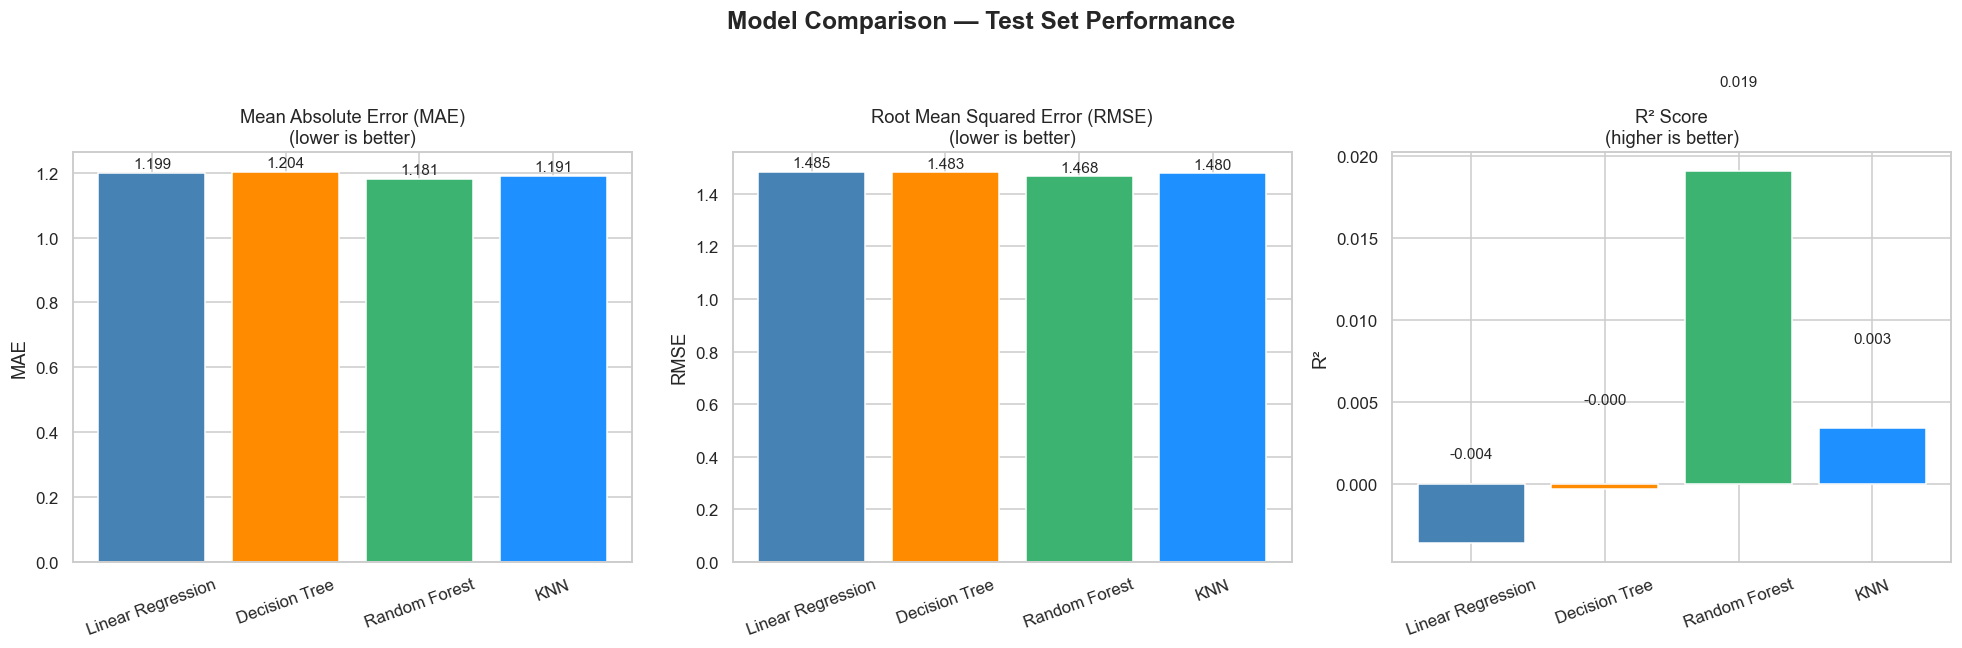

In [33]:
# ── Bar chart comparison — MAE, Test RMSE, R² ──

algorithm_names = comparison_df["Algorithm"].tolist()
bar_colors      = ["steelblue", "darkorange", "mediumseagreen", "dodgerblue"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — Test Set Performance", fontsize=16, fontweight="bold")

# --- MAE ---
bars = axes[0].bar(algorithm_names, comparison_df["MAE"], color=bar_colors, edgecolor="white")
axes[0].set_title("Mean Absolute Error (MAE)\n(lower is better)", fontsize=12)
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, comparison_df["MAE"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=10)

# --- RMSE ---
bars = axes[1].bar(algorithm_names, comparison_df["RMSE (Test)"], color=bar_colors, edgecolor="white")
axes[1].set_title("Root Mean Squared Error (RMSE)\n(lower is better)", fontsize=12)
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, comparison_df["RMSE (Test)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=10)

# --- R² ---
bars = axes[2].bar(algorithm_names, comparison_df["R² (Test)"], color=bar_colors, edgecolor="white")
axes[2].set_title("R² Score\n(higher is better)", fontsize=12)
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, comparison_df["R² (Test)"]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

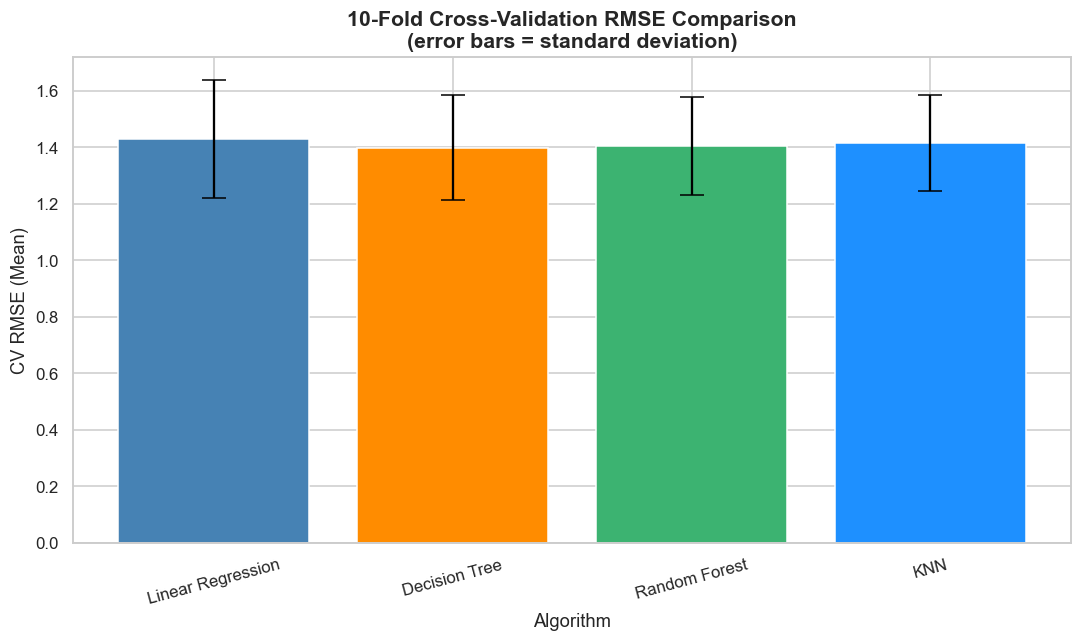

In [34]:
# ── Cross-Validation RMSE Comparison (error bars = std deviation) ──

plt.figure(figsize=(10, 6))
plt.bar(
    algorithm_names,
    comparison_df["CV RMSE (Mean)"],
    yerr=comparison_df["CV RMSE (Std)"],          # Error bars show variability across folds
    color=bar_colors,
    edgecolor="white",
    capsize=8,                                     # End-caps on error bars
    ecolor="black"
)
plt.title("10-Fold Cross-Validation RMSE Comparison\n(error bars = standard deviation)",
          fontsize=14, fontweight="bold")
plt.xlabel("Algorithm")
plt.ylabel("CV RMSE (Mean)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

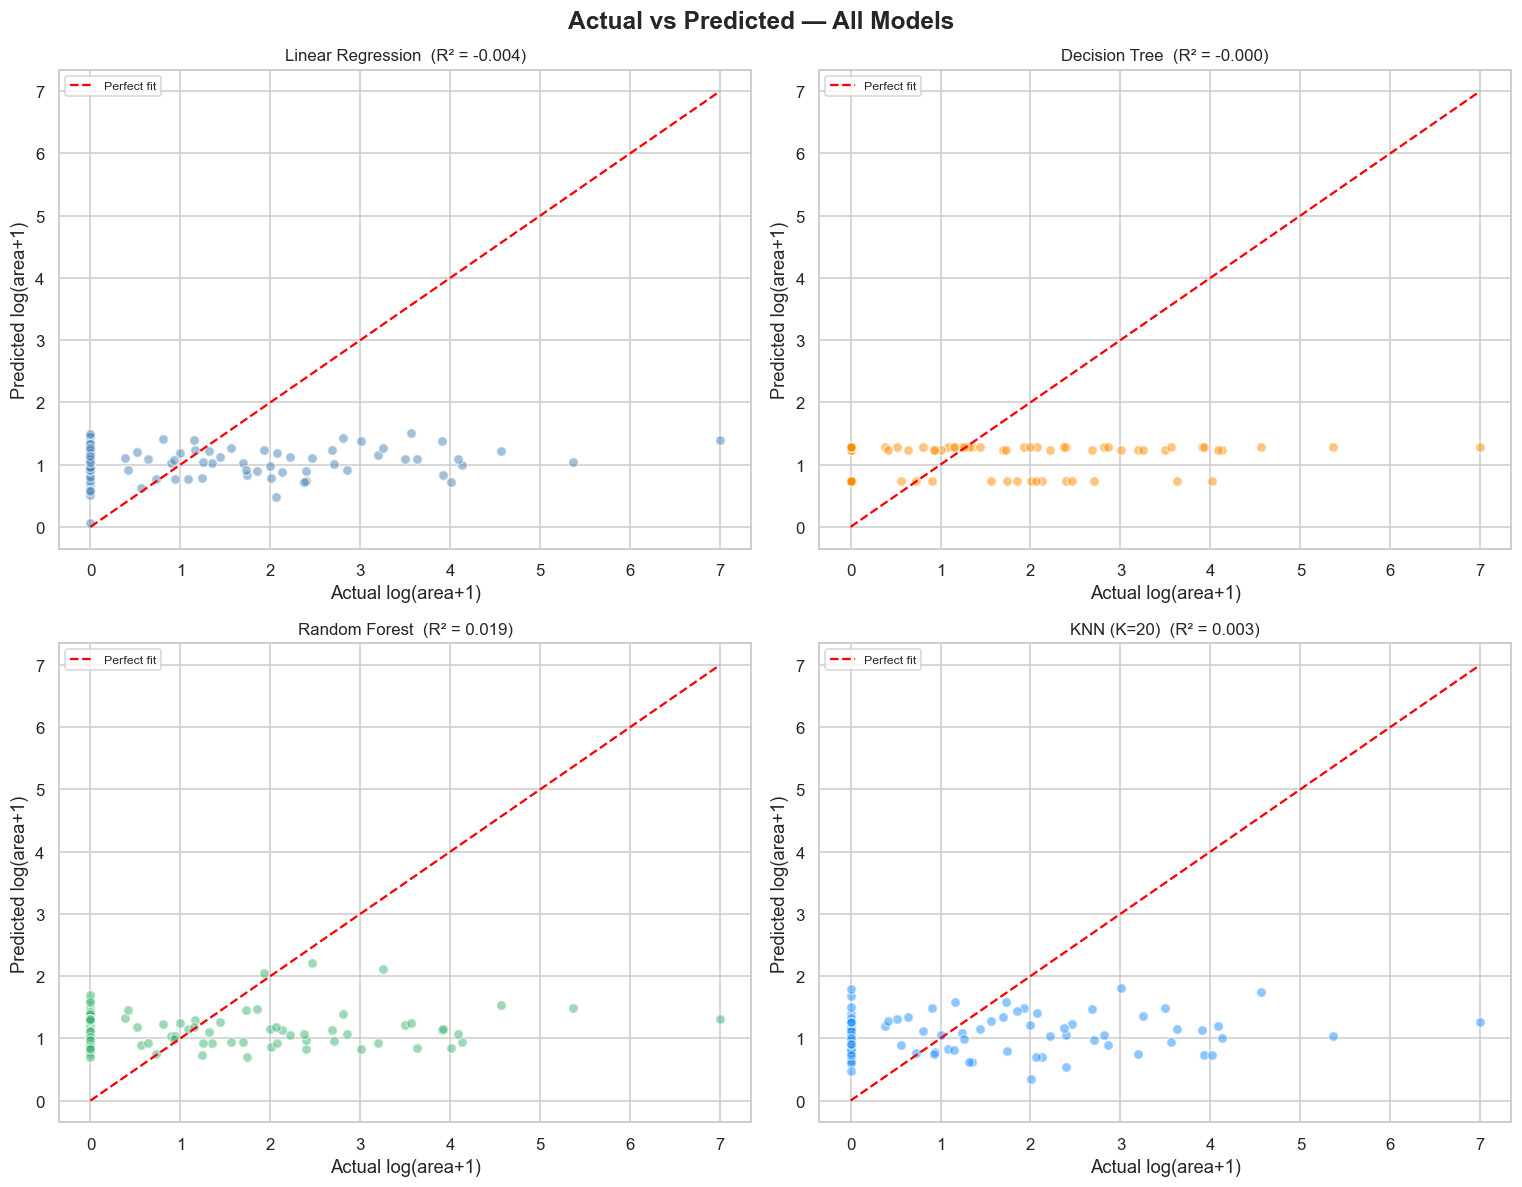

In [35]:
# ── Overlay: Actual vs Predicted for all 4 models in one plot ──

all_predictions = {
    "Linear Regression"   : y_pred_linear,
    "Decision Tree"       : y_pred_dt,
    "Random Forest"       : y_pred_rf,
    f"KNN (K={best_k})"   : y_pred_knn,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Actual vs Predicted — All Models", fontsize=16, fontweight="bold")
axes = axes.flatten()

plot_colors = ["steelblue", "darkorange", "mediumseagreen", "dodgerblue"]

for idx, (model_label, preds) in enumerate(all_predictions.items()):
    axes[idx].scatter(y_test.values, preds, alpha=0.5, color=plot_colors[idx], s=40, edgecolors="white")
    min_v, max_v = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    axes[idx].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.5, label="Perfect fit")
    r2_val = all_results[list(all_results.keys())[idx]]["r2"]
    axes[idx].set_title(f"{model_label}  (R² = {r2_val:.3f})", fontsize=11)
    axes[idx].set_xlabel("Actual log(area+1)")
    axes[idx].set_ylabel("Predicted log(area+1)")
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
# ── Summary and Conclusion ──

print("=" * 75)
print(" SUMMARY & CONCLUSION")
print("=" * 75)
print()
print("All models predict log(area+1). Lower RMSE/MAE = better. Higher R² = better.")
print()
print(comparison_df.set_index("Algorithm").to_string())
print()
print("-" * 75)
print(f"  Best overall by CV RMSE (most reliable): {best_cv}")
print(f"  Best overall by Test R²                : {best_r2}")
print()
print("Key Takeaways:")
print("  1. The target 'area' is highly skewed, so log(x+1) transformation was applied.")
print("  2. Random Forest generally outperforms a single Decision Tree due to ensembling.")
print("  3. Linear Regression performs well when relationships are roughly linear.")
print("  4. KNN performance heavily depends on the choice of K and feature scaling.")
print("  5. Cross-validation gives a more honest estimate than a single train/test split.")
print("-" * 75)

 SUMMARY & CONCLUSION

All models predict log(area+1). Lower RMSE/MAE = better. Higher R² = better.

                      MAE  RMSE (Test)  R² (Test)  CV RMSE (Mean)  CV RMSE (Std)
Algorithm                                                                       
Linear Regression  1.1992       1.4852    -0.0036          1.4305         0.2086
Decision Tree      1.2037       1.4828    -0.0003          1.3995         0.1860
Random Forest      1.1813       1.4683     0.0191          1.4063         0.1732
KNN                1.1906       1.4800     0.0034          1.4157         0.1716

---------------------------------------------------------------------------
  Best overall by CV RMSE (most reliable): Decision Tree
  Best overall by Test R²                : Random Forest

Key Takeaways:
  1. The target 'area' is highly skewed, so log(x+1) transformation was applied.
  2. Random Forest generally outperforms a single Decision Tree due to ensembling.
  3. Linear Regression performs well when 